In [164]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [165]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [166]:
# Binary cross-entropy loss
def compute_loss(y, hx):
    epsilon = 1e-10  # To avoid log(0)
    hx = np.clip(hx, epsilon, 1 - epsilon)
    return -np.mean(y * np.log(hx) + (1 - y) * np.log(1 - hx))

In [167]:
# Compute gradient
def compute_gradient(X, y, hx):
    return np.dot(X.T, hx - y) / y.shape[0]

In [168]:
df = pd.read_csv("data.csv")

In [169]:
# Normalize features (Age & Income)
df["Age"] = (df["Age"] - df["Age"].mean()) / df["Age"].std()
df["Income"] = (df["Income"] - df["Income"].mean()) / df["Income"].std()

In [170]:
# Prepare input features and target variable
X = np.array([df["Age"], df["Income"]]).T
y = df["Purchased"].values

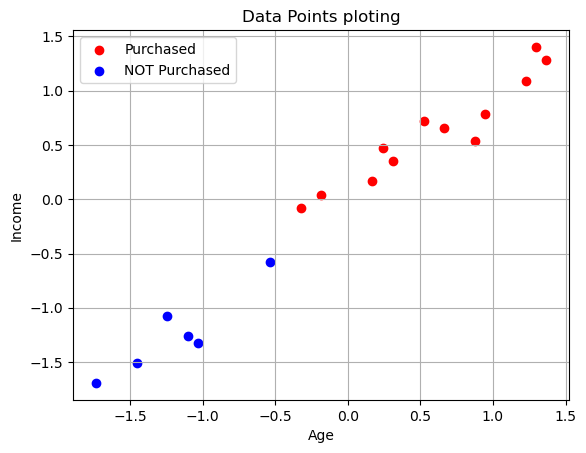

In [171]:
plt.scatter(df['Age'][df['Purchased'] == 1],df['Income'][df['Purchased'] == 1],c='red',label = 'Purchased')
plt.scatter(df['Age'][df['Purchased'] == 0],df['Income'][df['Purchased'] == 0],c='blue',label = 'NOT Purchased')
plt.title('Data Points ploting')
plt.xlabel('Age')
plt.ylabel('Income')
plt.legend()
plt.grid(True)
plt.show()

In [172]:
def plot_decision_boundary(X, y, weights):
    plt.scatter(df['Age'][df['Purchased'] == 1], df['Income'][df['Purchased'] == 1], c='red', label='Purchased')
    plt.scatter(df['Age'][df['Purchased'] == 0], df['Income'][df['Purchased'] == 0], c='blue', label='Not Purchased')

    # Create a line for the decision boundary
    x_values = np.linspace(df['Age'].min(), df['Age'].max(), 100)
    y_values = -(weights[0] + weights[1] * x_values) / weights[2]

    plt.plot(x_values, y_values, 'k--', label="Decision Boundary")
    plt.xlabel("Age")
    plt.ylabel("Income")
    plt.legend()
    plt.grid(True)
    plt.title("Decision Boundary Plot")
    plt.show()

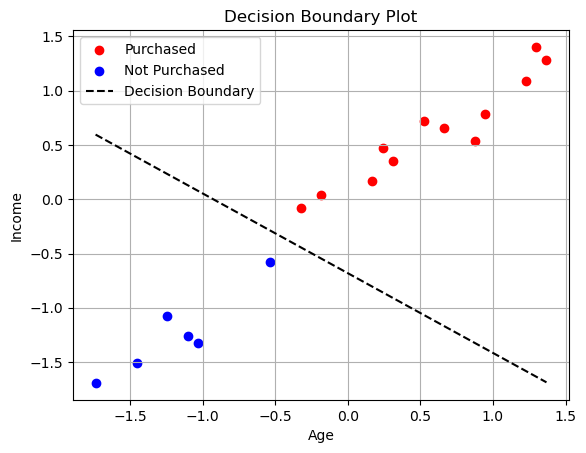

In [173]:
def Logistic_regressiion(X,y,Learning_rate = 0.1,num_iterations = 1000):
    # Add Intercert term to X
    X = np.hstack((np.ones((X.shape[0],1)),X))

    weights = np.zeros(X.shape[1]) 
    loss_history = []
    # weights is the thetea theta0
    for i in range(num_iterations):
        z = np.dot(X,weights)
        hx = sigmoid(z)
        loss = compute_loss(y,hx)
        gradient = compute_gradient(X,y,hx)
        weights -= Learning_rate*gradient
        loss_history.append(loss)
    return weights

weights = Logistic_regressiion(X,y)
plot_decision_boundary(X,y,weights)


        

In [174]:
# def plot_decision_boundary(X,y,weights,loss,iteration):
#     plt.scatter(df['Age'][y == 1],df['Income'][y == 1],c='red',label = 'Purchased')
#     plt.scatter(df['Age'][y == 0],df['Income'][y == 0],c='blue',label = 'NOT Purchased')
#     x_values = np.linspace(-10,80,400)
#     y_values = -(weights[0] + weights[1]*x_values)/weights[2]
#     plt.plot(x_values,y_values,linestyle = '--',c = 'grey',label = 'Decision line')
#     plt.title(f'Data line at iteration = {iteration}, loss = {loss},wieghts = {weights}')
#     plt.ylim([2,8])
#     plt.xlabel('Age')
#     plt.ylabel('Income')
#     plt.legend()
#     plt.grid(True)
#     plt.show()

In [175]:
weights

array([2.23894473, 2.41616781, 3.28713049])